
# SWEC-ETHZ short-term: LOSO feature selection

This notebook is the **first machine-learning notebook** after preprocessing.

It does four things:
1. loads the window-level feature table created in preprocessing,
2. explains the labels and class balance,
3. runs **leave-one-subject-out (LOSO)** feature selection,
4. saves the selected feature lists so the later model notebook can reuse them.

The notebook is written to be beginner-friendly:
- one row = one EEG window,
- one column = one extracted feature,
- `subject_id` = patient,
- `target` = the label for that window.

For now we use a **binary target**:
- `seizure` = 1
- `non_seizure` = 0

Why binary first?
- easier to understand,
- easier to evaluate,
- easier to connect to later HMM post-processing.



## Why we normalize features

Most EEG features live on different numeric scales.
For example, means, amplitudes, and line length can have very different ranges.

That matters because many models and feature-selection methods compare features numerically.
So we use **StandardScaler**:

\[
 z = rac{x - \mu_{train}}{\sigma_{train}}
\]

Important: in LOSO, the scaler must be fit on the **training subjects only**, then applied to the held-out subject.
Otherwise we would leak information from the test subject into training.



## What this notebook will save

At the end, the notebook writes:
- a table with **per-fold class balance**,
- a table with **per-fold metrics for the feature-selection stage**,
- a table with **which features were selected in each fold**,
- a **feature stability summary** showing how often each feature was selected across held-out subjects.

Those files will be used later by the model-training notebook.


In [35]:

# Core imports
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    mutual_info_classif,
    SequentialFeatureSelector,
    RFE,
    RFECV,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [38]:

# ---------------------------
# Input / output paths
# ---------------------------
FEATURES_DIR = Path("../data/synthetic/simulated_swec_features_package/derived_features_swec_short")
FEATURES_PARQUET = FEATURES_DIR / "all_window_features.parquet"
FEATURES_CSV = FEATURES_DIR / "all_window_features.csv"
MANIFEST_CSV = FEATURES_DIR / "recording_manifest.csv"
PARTICIPANT_SUMMARY_CSV = FEATURES_DIR / "participant_summary.csv"

OUTPUT_DIR = Path("derived_ml_swec_short")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Analysis setup
# ---------------------------
TARGET_COLUMN = "target"
POSITIVE_LABEL = "seizure"
NEGATIVE_LABEL = "non_seizure"
SUBJECT_COLUMN = "subject_id"
RECORDING_COLUMN = "recording_id"
WINDOW_INDEX_COLUMN = "window_idx"

# Set to a small list like ["ID1", "ID2"] for a smoke test, or None for all subjects.
SUBJECT_IDS = None


# ---------------------------
# Feature-selection method
# Choose one of:
#   "variance_threshold"
#   "filter_f_classif"
#   "filter_mutual_info"
#   "forward_wrapper"
#   "backward_wrapper"
#   "rfe"
#   "boruta"
# ---------------------------
FS_METHOD = "filter_f_classif"

# Some methods use a scoring metric during selection.
# Good beginner defaults: "balanced_accuracy", "f1", "roc_auc"
FS_SCORING = "balanced_accuracy"

# Wrapper methods and RFE can run in two modes:
#   "fixed_k"     -> keep exactly N_FEATURES_TO_SELECT features
#   "metric_stop" -> stop automatically based on validation score
FS_SELECTION_MODE = "fixed_k"

# Used when FS_SELECTION_MODE == "fixed_k"
N_FEATURES_TO_SELECT = 20

# Used when FS_SELECTION_MODE == "metric_stop"
# For forward/backward wrapper methods, sklearn's SequentialFeatureSelector
# uses n_features_to_select="auto" together with tol.
# For RFE, metric-stop mode uses RFECV.
MIN_FEATURES_TO_SELECT = 5
SFS_TOL = 0.001
RFE_STEP = 1

# Variance threshold parameter
VARIANCE_THRESHOLD_VALUE = 0.0

# Base estimator for model-based feature selection methods
# Options in this notebook: "logreg", "linear_svm", "random_forest"
BASE_ESTIMATOR_NAME = "logreg"

# Reproducibility
RANDOM_STATE = 42



## Feature selection methods available in this notebook

Set the method with `FS_METHOD`.

Set how many features to keep with `FS_SELECTION_MODE`:

```python
FS_SELECTION_MODE = "fixed_k"      # exact number of features
N_FEATURES_TO_SELECT = 20

# or

FS_SELECTION_MODE = "metric_stop"  # stop automatically based on validation score
MIN_FEATURES_TO_SELECT = 5
SFS_TOL = 0.001
```

### `variance_threshold`
Removes features with very low variance.

Use:
```python
FS_METHOD = "variance_threshold"
VARIANCE_THRESHOLD_VALUE = 0.0
```

Uses:
- `VARIANCE_THRESHOLD_VALUE`

Does not use:
- `N_FEATURES_TO_SELECT`
- `FS_SCORING`
- `BASE_ESTIMATOR_NAME`

### `filter_f_classif`
Ranks features with an ANOVA F-test and keeps the top `k`.

Use:
```python
FS_METHOD = "filter_f_classif"
N_FEATURES_TO_SELECT = 20
```

Uses:
- `N_FEATURES_TO_SELECT`

### `filter_mutual_info`
Ranks features by mutual information with the label and keeps the top `k`.

Use:
```python
FS_METHOD = "filter_mutual_info"
N_FEATURES_TO_SELECT = 20
```

Uses:
- `N_FEATURES_TO_SELECT`

### `forward_wrapper`
Starts with no features and adds them one by one using a model.

Fixed-size mode:
```python
FS_METHOD = "forward_wrapper"
FS_SELECTION_MODE = "fixed_k"
BASE_ESTIMATOR_NAME = "logreg"
FS_SCORING = "balanced_accuracy"
N_FEATURES_TO_SELECT = 20
```

Metric-stop mode:
```python
FS_METHOD = "forward_wrapper"
FS_SELECTION_MODE = "metric_stop"
BASE_ESTIMATOR_NAME = "logreg"
FS_SCORING = "balanced_accuracy"
MIN_FEATURES_TO_SELECT = 5
SFS_TOL = 0.001
```

Uses:
- `BASE_ESTIMATOR_NAME`
- `FS_SCORING`
- either `N_FEATURES_TO_SELECT` or `MIN_FEATURES_TO_SELECT` + `SFS_TOL`

### `backward_wrapper`
Starts with all features and removes them one by one using a model.

Fixed-size mode:
```python
FS_METHOD = "backward_wrapper"
FS_SELECTION_MODE = "fixed_k"
BASE_ESTIMATOR_NAME = "logreg"
FS_SCORING = "balanced_accuracy"
N_FEATURES_TO_SELECT = 20
```

Metric-stop mode:
```python
FS_METHOD = "backward_wrapper"
FS_SELECTION_MODE = "metric_stop"
BASE_ESTIMATOR_NAME = "logreg"
FS_SCORING = "balanced_accuracy"
MIN_FEATURES_TO_SELECT = 5
SFS_TOL = 0.001
```

Uses:
- `BASE_ESTIMATOR_NAME`
- `FS_SCORING`
- either `N_FEATURES_TO_SELECT` or `MIN_FEATURES_TO_SELECT` + `SFS_TOL`

### `rfe`
Recursively removes weak features according to a model.

Fixed-size mode:
```python
FS_METHOD = "rfe"
FS_SELECTION_MODE = "fixed_k"
BASE_ESTIMATOR_NAME = "logreg"
N_FEATURES_TO_SELECT = 20
```

Metric-stop mode:
```python
FS_METHOD = "rfe"
FS_SELECTION_MODE = "metric_stop"
BASE_ESTIMATOR_NAME = "logreg"
FS_SCORING = "balanced_accuracy"
MIN_FEATURES_TO_SELECT = 5
RFE_STEP = 1
```

In metric-stop mode, the notebook uses `RFECV`, which chooses the number of features by cross-validation.

Uses:
- `BASE_ESTIMATOR_NAME`
- fixed-size mode: `N_FEATURES_TO_SELECT`
- metric-stop mode: `FS_SCORING`, `MIN_FEATURES_TO_SELECT`, `RFE_STEP`

### `boruta`
Tree-based feature selection that keeps features that are more informative than randomized shadow features.

Use:
```python
FS_METHOD = "boruta"
```

Uses:
- Boruta's internal decision rule
- the `boruta` package must be installed

### Choosing the internal model
Some methods need a model to judge feature usefulness. Choose it with:

```python
BASE_ESTIMATOR_NAME = "logreg"
```

Available options:
- `"logreg"`
- `"linear_svm"`
- `"random_forest"`

### Choosing the scoring metric
Methods that evaluate performance during feature selection use:

```python
FS_SCORING = "balanced_accuracy"
```

Common options:
- `"balanced_accuracy"`
- `"f1"`
- `"roc_auc"`


In [39]:

# Metadata columns from preprocessing.
# Everything numeric outside this list becomes a candidate feature.
META_COLUMNS = {
    "subject_id",
    "recording_id",
    "fileName",
    "window_idx",
    "window_start_s",
    "window_end_s",
    "window_mid_s",
    "crop_start_s",
    "crop_end_s",
    "seizure_start_s",
    "seizure_end_s",
    "original_n_channels",
    "n_channels",
    "label_strategy",
    "seizure_fraction_in_window",
    "target",
}


def load_feature_table():
    if FEATURES_PARQUET.exists():
        return pd.read_parquet(FEATURES_PARQUET)
    if FEATURES_CSV.exists():
        return pd.read_csv(FEATURES_CSV)
    raise FileNotFoundError(
        f"Could not find feature table at {FEATURES_PARQUET} or {FEATURES_CSV}."
    )


all_df = load_feature_table()
manifest_df = pd.read_csv(MANIFEST_CSV) if MANIFEST_CSV.exists() else pd.DataFrame()
participant_summary_df = pd.read_csv(PARTICIPANT_SUMMARY_CSV) if PARTICIPANT_SUMMARY_CSV.exists() else pd.DataFrame()

if SUBJECT_IDS is not None:
    all_df = all_df[all_df[SUBJECT_COLUMN].isin(SUBJECT_IDS)].copy()

all_df = all_df.reset_index(drop=True)
print("Rows (windows):", len(all_df))
print("Subjects:", all_df[SUBJECT_COLUMN].nunique())
print("Recordings:", all_df[RECORDING_COLUMN].nunique())


Rows (windows): 240
Subjects: 5
Recordings: 10


In [40]:

# Build the binary target.
label_counts = all_df[TARGET_COLUMN].value_counts(dropna=False)
print(label_counts)

valid_mask = all_df[TARGET_COLUMN].isin([POSITIVE_LABEL, NEGATIVE_LABEL])
df = all_df.loc[valid_mask].copy()
df["target_binary"] = (df[TARGET_COLUMN] == POSITIVE_LABEL).astype(int)

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [
    c for c in numeric_columns
    if c not in META_COLUMNS and c != "target_binary"
]

print("Candidate feature columns:", len(feature_columns))
print("Example features:", feature_columns[:10])


target
non_seizure    120
seizure        120
Name: count, dtype: int64
Candidate feature columns: 103
Example features: ['is_seizure_window', 'crop_duration_s', 'fs', 'line_length__ch01', 'line_length__ch02', 'line_length__ch03', 'line_length__ch04', 'line_length__ch05', 'line_length__ch06', 'line_length__ch07']



## Quick dataset report

The next cells answer beginner questions such as:
- How many windows are seizure vs non-seizure?
- Are some subjects much more imbalanced than others?
- How many recordings contribute to each subject?


In [41]:

# Overall label balance
overall_balance = (
    df["target_binary"]
      .value_counts()
      .rename(index={0: NEGATIVE_LABEL, 1: POSITIVE_LABEL})
      .rename_axis("label")
      .reset_index(name="n_windows")
)
overall_balance["fraction"] = overall_balance["n_windows"] / overall_balance["n_windows"].sum()
overall_balance


,label,n_windows,fraction
0,non_seizure,120,0.5
1,seizure,120,0.5


In [42]:

# Per-subject label balance
subject_balance = (
    df.groupby(SUBJECT_COLUMN)["target_binary"]
      .agg(n_windows="count", n_seizure="sum")
      .reset_index()
)
subject_balance["n_non_seizure"] = subject_balance["n_windows"] - subject_balance["n_seizure"]
subject_balance["seizure_fraction"] = subject_balance["n_seizure"] / subject_balance["n_windows"]
subject_balance = subject_balance.sort_values(SUBJECT_COLUMN).reset_index(drop=True)
subject_balance


,subject_id,n_windows,n_seizure,n_non_seizure,seizure_fraction
0,SIM1,48,24,24,0.5
1,SIM2,48,24,24,0.5
2,SIM3,48,24,24,0.5
3,SIM4,48,24,24,0.5
4,SIM5,48,24,24,0.5


In [43]:

# Merge in recording counts from the preprocessing manifest if available
if not manifest_df.empty:
    recording_counts = (
        manifest_df[manifest_df.get("used_for_model", True).fillna(True)]
        .groupby("subject_id")
        .size()
        .rename("n_recordings")
        .reset_index()
    )
    subject_overview = subject_balance.merge(recording_counts, on="subject_id", how="left")
else:
    subject_overview = subject_balance.copy()

subject_overview = subject_overview.sort_values("subject_id").reset_index(drop=True)
subject_overview


,subject_id,n_windows,n_seizure,n_non_seizure,seizure_fraction,n_recordings
0,SIM1,48,24,24,0.5,2
1,SIM2,48,24,24,0.5,2
2,SIM3,48,24,24,0.5,2
3,SIM4,48,24,24,0.5,2
4,SIM5,48,24,24,0.5,2


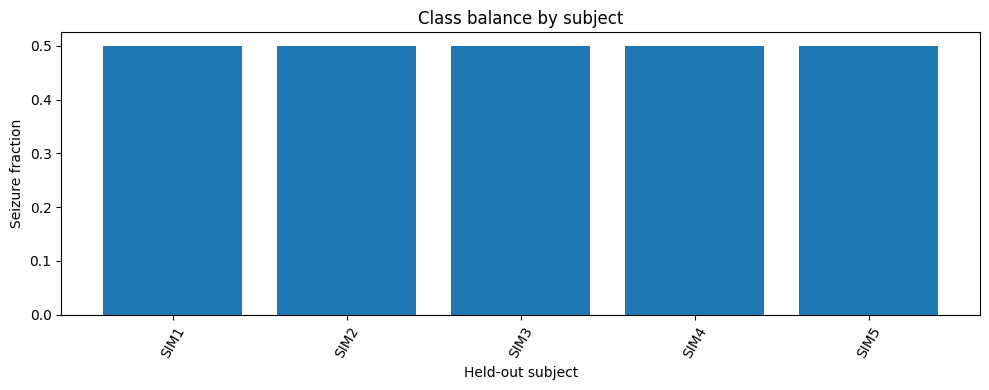

In [44]:

# Simple plot: seizure fraction by subject
plt.figure(figsize=(10, 4))
plt.bar(subject_balance[SUBJECT_COLUMN], subject_balance["seizure_fraction"])
plt.xticks(rotation=60)
plt.ylabel("Seizure fraction")
plt.xlabel("Held-out subject")
plt.title("Class balance by subject")
plt.tight_layout()
plt.show()



## Helper functions

These functions keep the LOSO loop readable.
They handle:
- choosing the base estimator,
- scaling inside each fold,
- fitting the selected feature-selection method,
- extracting the names of the chosen features.


In [45]:

def get_base_estimator(name: str, random_state: int = 42):
    if name == "logreg":
        return LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="liblinear",
            random_state=random_state,
        )
    if name == "linear_svm":
        return LinearSVC(
            class_weight="balanced",
            dual="auto",
            random_state=random_state,
        )
    if name == "random_forest":
        return RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        )
    raise ValueError(f"Unknown BASE_ESTIMATOR_NAME: {name}")


def make_fs_selector(
    method: str,
    selection_mode: str,
    n_features: int,
    min_features: int,
    scoring: str,
    estimator_name: str,
    random_state: int = 42,
):
    estimator = get_base_estimator(estimator_name, random_state=random_state)

    if method == "variance_threshold":
        return VarianceThreshold(threshold=VARIANCE_THRESHOLD_VALUE)

    if method == "filter_f_classif":
        return SelectKBest(score_func=f_classif, k=min(n_features, len(feature_columns)))

    if method == "filter_mutual_info":
        def mi_score(X, y):
            return mutual_info_classif(X, y, random_state=random_state)
        return SelectKBest(score_func=mi_score, k=min(n_features, len(feature_columns)))

    if method == "forward_wrapper":
        if selection_mode == "fixed_k":
            return SequentialFeatureSelector(
                estimator=estimator,
                n_features_to_select=min(n_features, len(feature_columns)),
                direction="forward",
                scoring=scoring,
                n_jobs=-1,
                cv=3,
            )
        if selection_mode == "metric_stop":
            return SequentialFeatureSelector(
                estimator=estimator,
                n_features_to_select="auto",
                tol=abs(SFS_TOL),
                direction="forward",
                scoring=scoring,
                n_jobs=-1,
                cv=3,
            )
        raise ValueError(f"Unknown FS_SELECTION_MODE: {selection_mode}")

    if method == "backward_wrapper":
        if selection_mode == "fixed_k":
            return SequentialFeatureSelector(
                estimator=estimator,
                n_features_to_select=min(n_features, len(feature_columns)),
                direction="backward",
                scoring=scoring,
                n_jobs=-1,
                cv=3,
            )
        if selection_mode == "metric_stop":
            return SequentialFeatureSelector(
                estimator=estimator,
                n_features_to_select="auto",
                tol=-abs(SFS_TOL),
                direction="backward",
                scoring=scoring,
                n_jobs=-1,
                cv=3,
            )
        raise ValueError(f"Unknown FS_SELECTION_MODE: {selection_mode}")

    if method == "rfe":
        est = estimator
        if selection_mode == "fixed_k":
            return RFE(
                estimator=est,
                n_features_to_select=min(n_features, len(feature_columns)),
                step=RFE_STEP,
            )
        if selection_mode == "metric_stop":
            return RFECV(
                estimator=est,
                step=RFE_STEP,
                cv=3,
                scoring=scoring,
                min_features_to_select=min(min_features, len(feature_columns)),
                n_jobs=-1,
            )
        raise ValueError(f"Unknown FS_SELECTION_MODE: {selection_mode}")

    if method == "boruta":
        try:
            from boruta import BorutaPy
        except Exception as e:
            raise ImportError(
                "Boruta was requested, but the 'boruta' package is not installed. "
                "Install it first or choose another FS method."
            ) from e

        rf = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        )
        return BorutaPy(
            estimator=rf,
            n_estimators='auto',
            random_state=random_state,
            verbose=0,
        )

    raise ValueError(f"Unknown FS method: {method}")


def fit_selector_and_get_features(selector, X_train_scaled, y_train, feature_names):
    selector.fit(X_train_scaled, y_train)

    if hasattr(selector, "get_support"):
        support = selector.get_support()
        selected = [name for name, keep in zip(feature_names, support) if keep]
    elif hasattr(selector, "support_"):
        support = selector.support_
        selected = [name for name, keep in zip(feature_names, support) if keep]
    else:
        raise ValueError("Could not extract selected features from the selector.")

    return selected


def score_selected_features_with_simple_model(X_train_sel, y_train, X_test_sel, y_test, random_state=42):
    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=random_state,
    )
    clf.fit(X_train_sel, y_train)
    y_pred = clf.predict(X_test_sel)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test_sel)[:, 1]
    else:
        y_score = y_pred.astype(float)

    out = {
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    }

    if len(np.unique(y_test)) == 2:
        out["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        out["roc_auc"] = np.nan

    return out, y_pred, y_score



## LOSO feature selection

For each fold:
- one `subject_id` is held out,
- all other subjects are used for training,
- the scaler is fit on training windows only,
- feature selection is fit on training windows only,
- the selected subset is evaluated on the held-out subject with a simple logistic regression.

That simple classifier is used here only to make the feature-selection step tangible.
The dedicated model notebook will later compare many models fairly on the selected features.


For wrapper methods and RFE, this notebook supports either a fixed number of features or automatic stopping based on validation score.

In [53]:
FS_METHOD = "rfe"
FS_SELECTION_MODE = "metric_stop"
BASE_ESTIMATOR_NAME = "logreg"
FS_SCORING = "balanced_accuracy"
MIN_FEATURES_TO_SELECT = 5
RFE_STEP = 1

In [54]:

subjects = sorted(df[SUBJECT_COLUMN].unique())

fold_rows = []
selection_rows = []
balance_rows = []
prediction_rows = []

for held_out_subject in subjects:
    train_df = df[df[SUBJECT_COLUMN] != held_out_subject].copy()
    test_df = df[df[SUBJECT_COLUMN] == held_out_subject].copy()

    X_train = train_df[feature_columns].copy()
    y_train = train_df["target_binary"].copy()
    X_test = test_df[feature_columns].copy()
    y_test = test_df["target_binary"].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    selector = make_fs_selector(
        method=FS_METHOD,
        selection_mode=FS_SELECTION_MODE,
        n_features=N_FEATURES_TO_SELECT,
        min_features=MIN_FEATURES_TO_SELECT,
        scoring=FS_SCORING,
        estimator_name=BASE_ESTIMATOR_NAME,
        random_state=RANDOM_STATE,
    )

    selected_features = fit_selector_and_get_features(
        selector=selector,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        feature_names=feature_columns,
    )

    if len(selected_features) == 0:
        raise ValueError(f"Fold {held_out_subject} selected zero features.")

    selected_idx = [feature_columns.index(f) for f in selected_features]
    X_train_sel = X_train_scaled[:, selected_idx]
    X_test_sel = X_test_scaled[:, selected_idx]

    metrics, y_pred, y_score = score_selected_features_with_simple_model(
        X_train_sel, y_train, X_test_sel, y_test, random_state=RANDOM_STATE
    )

    fold_rows.append({
        "held_out_subject": held_out_subject,
        "fs_method": FS_METHOD,
        "fs_scoring": FS_SCORING,
        "base_estimator": BASE_ESTIMATOR_NAME,
        "n_train_windows": len(train_df),
        "n_test_windows": len(test_df),
        "n_selected_features": len(selected_features),
        "fs_selection_mode": FS_SELECTION_MODE,
        **metrics,
    })

    balance_rows.append({
        "held_out_subject": held_out_subject,
        "train_windows": len(train_df),
        "train_seizure": int(y_train.sum()),
        "train_non_seizure": int((1 - y_train).sum()),
        "train_seizure_fraction": float(y_train.mean()),
        "test_windows": len(test_df),
        "test_seizure": int(y_test.sum()),
        "test_non_seizure": int((1 - y_test).sum()),
        "test_seizure_fraction": float(y_test.mean()),
    })

    for rank, feat in enumerate(selected_features, start=1):
        selection_rows.append({
            "held_out_subject": held_out_subject,
            "rank_in_list": rank,
            "feature_name": feat,
            "fs_method": FS_METHOD,
            "fs_scoring": FS_SCORING,
            "base_estimator": BASE_ESTIMATOR_NAME,
        })

    pred_fold = test_df[[SUBJECT_COLUMN, RECORDING_COLUMN, WINDOW_INDEX_COLUMN, TARGET_COLUMN, "target_binary"]].copy()
    pred_fold["held_out_subject"] = held_out_subject
    pred_fold["y_pred"] = y_pred
    pred_fold["y_score"] = y_score
    prediction_rows.append(pred_fold)

    print(f"Finished fold {held_out_subject}: selected {len(selected_features)} features")

fold_results_df = pd.DataFrame(fold_rows).sort_values("held_out_subject").reset_index(drop=True)
selection_df = pd.DataFrame(selection_rows).sort_values(["held_out_subject", "rank_in_list"]).reset_index(drop=True)
balance_df = pd.DataFrame(balance_rows).sort_values("held_out_subject").reset_index(drop=True)
predictions_df = pd.concat(prediction_rows, axis=0).reset_index(drop=True)


Finished fold SIM1: selected 5 features
Finished fold SIM2: selected 5 features
Finished fold SIM3: selected 5 features
Finished fold SIM4: selected 5 features
Finished fold SIM5: selected 5 features


In [55]:

fold_results_df


,held_out_subject,fs_method,fs_scoring,base_estimator,n_train_windows,n_test_windows,n_selected_features,fs_selection_mode,balanced_accuracy,f1,precision,recall,roc_auc
0,SIM1,rfe,balanced_accuracy,logreg,192,48,5,metric_stop,1.0,1.0,1.0,1.0,1.0
1,SIM2,rfe,balanced_accuracy,logreg,192,48,5,metric_stop,1.0,1.0,1.0,1.0,1.0
2,SIM3,rfe,balanced_accuracy,logreg,192,48,5,metric_stop,1.0,1.0,1.0,1.0,1.0
3,SIM4,rfe,balanced_accuracy,logreg,192,48,5,metric_stop,1.0,1.0,1.0,1.0,1.0
4,SIM5,rfe,balanced_accuracy,logreg,192,48,5,metric_stop,1.0,1.0,1.0,1.0,1.0


In [56]:

balance_df


,held_out_subject,train_windows,train_seizure,train_non_seizure,train_seizure_fraction,test_windows,test_seizure,test_non_seizure,test_seizure_fraction
0,SIM1,192,96,96,0.5,48,24,24,0.5
1,SIM2,192,96,96,0.5,48,24,24,0.5
2,SIM3,192,96,96,0.5,48,24,24,0.5
3,SIM4,192,96,96,0.5,48,24,24,0.5
4,SIM5,192,96,96,0.5,48,24,24,0.5



## Feature stability across LOSO folds

A useful question is:

**Which features are selected again and again across different held-out subjects?**

Those are often the most promising features to inspect later.


In [57]:

feature_stability_df = (
    selection_df.groupby("feature_name")
    .agg(
        selected_in_folds=("held_out_subject", "count"),
        first_fold=("held_out_subject", "min"),
    )
    .reset_index()
    .sort_values(["selected_in_folds", "feature_name"], ascending=[False, True])
    .reset_index(drop=True)
)
feature_stability_df["selection_fraction"] = feature_stability_df["selected_in_folds"] / len(subjects)
feature_stability_df.head(30)


,feature_name,selected_in_folds,first_fold,selection_fraction
0,amp_var__ch02,5,SIM1,1.0
1,is_seizure_window,5,SIM1,1.0
2,line_length__ch04,4,SIM2,0.8
3,amp_var__ch07,3,SIM2,0.6
4,amp_var__ch04,2,SIM1,0.4
5,amp_var__ch01,1,SIM3,0.2
6,line_length__ch01,1,SIM5,0.2
7,line_length__ch08,1,SIM2,0.2
8,max__ch02,1,SIM1,0.2
9,max__ch07,1,SIM1,0.2


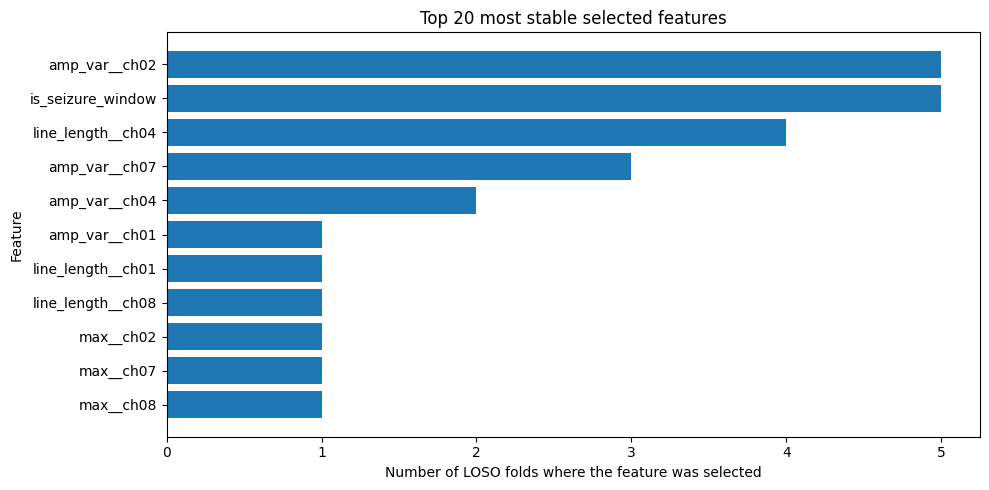

In [58]:

plt.figure(figsize=(10, 5))
plot_df = feature_stability_df.head(20).iloc[::-1]
plt.barh(plot_df["feature_name"], plot_df["selected_in_folds"])
plt.xlabel("Number of LOSO folds where the feature was selected")
plt.ylabel("Feature")
plt.title("Top 20 most stable selected features")
plt.tight_layout()
plt.show()



## Interpreting the results

A few beginner-friendly rules:

- If one subject has very different balance from the others, its LOSO fold may be much harder.
- If a feature appears in many folds, it may be more stable across subjects.
- Wrapper methods usually take longer than filter methods.
- Different feature-selection methods may prefer different subsets.
- A good feature subset for one model is not always optimal for another model.

That is why the next notebook should compare **multiple classifiers** on the same LOSO setup.


In [59]:

# Save outputs for the model notebook and later analysis
if FS_SELECTION_MODE == "fixed_k":
    fs_detail_tag = f"k-{N_FEATURES_TO_SELECT}"
else:
    fs_detail_tag = f"auto-min-{MIN_FEATURES_TO_SELECT}__tol-{SFS_TOL}__step-{RFE_STEP}"

fs_tag = f"{FS_METHOD}__mode-{FS_SELECTION_MODE}__score-{FS_SCORING}__base-{BASE_ESTIMATOR_NAME}__{fs_detail_tag}"
run_dir = OUTPUT_DIR / f"feature_selection__{fs_tag}"
run_dir.mkdir(parents=True, exist_ok=True)

fold_results_df.to_csv(run_dir / "fold_results.csv", index=False)
selection_df.to_csv(run_dir / "selected_features_by_fold.csv", index=False)
feature_stability_df.to_csv(run_dir / "feature_stability.csv", index=False)
balance_df.to_csv(run_dir / "fold_class_balance.csv", index=False)
predictions_df.to_csv(run_dir / "simple_probe_predictions.csv", index=False)

summary_txt = f"""
Feature selection run completed.
Run directory: {run_dir.resolve()}
Subjects: {len(subjects)}
FS method: {FS_METHOD}
FS selection mode: {FS_SELECTION_MODE}
FS scoring: {FS_SCORING}
Base estimator: {BASE_ESTIMATOR_NAME}
Requested features (fixed_k mode): {N_FEATURES_TO_SELECT}
Minimum features (metric_stop mode): {MIN_FEATURES_TO_SELECT}
SFS tolerance (metric_stop mode): {SFS_TOL}
RFE step: {RFE_STEP}
Average selected features: {fold_results_df['n_selected_features'].mean():.2f}
Mean balanced accuracy of the simple probe model: {fold_results_df['balanced_accuracy'].mean():.4f}
""".strip()

(run_dir / "run_summary.txt").write_text(summary_txt)

print(summary_txt)
print("Saved files:")
for p in sorted(run_dir.iterdir()):
    print("-", p.name)


Feature selection run completed.
Run directory: C:\Users\rescic\PycharmProjects\cobrabox\examples\derived_ml_swec_short\feature_selection__rfe__mode-metric_stop__score-balanced_accuracy__base-logreg__auto-min-5__tol-0.001__step-1
Subjects: 5
FS method: rfe
FS selection mode: metric_stop
FS scoring: balanced_accuracy
Base estimator: logreg
Requested features (fixed_k mode): 20
Minimum features (metric_stop mode): 5
SFS tolerance (metric_stop mode): 0.001
RFE step: 1
Average selected features: 5.00
Mean balanced accuracy of the simple probe model: 1.0000
Saved files:
- feature_stability.csv
- fold_class_balance.csv
- fold_results.csv
- run_summary.txt
- selected_features_by_fold.csv
- simple_probe_predictions.csv
